# Финальный проект: прогноз полезного сигнала на 50 секунд

Ниже реализован полный пайплайн: загрузка данных, обучение модели, расчет метрик из задания и визуализация результатов.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, root_mean_squared_error


## 1. Загрузка данных


In [4]:
train = pd.read_csv('sample_data/train.csv', header=None).to_numpy()
test = pd.read_csv('sample_data/test.csv', header=None).to_numpy()
etalon_train = pd.read_csv('sample_data/etalon_for_train.csv', header=None).to_numpy()
etalon_test = pd.read_csv('sample_data/etalon_for_test.csv', header=None).to_numpy()

print(f"train: {train.shape}")
print(f"test: {test.shape}")
print(f"etalon_train: {etalon_train.shape}")
print(f"etalon_test: {etalon_test.shape}")

train: (1000, 5000)
test: (500, 5000)
etalon_train: (1000, 5000)
etalon_test: (500, 5000)


## 2. Быстрая визуальная проверка сигналов


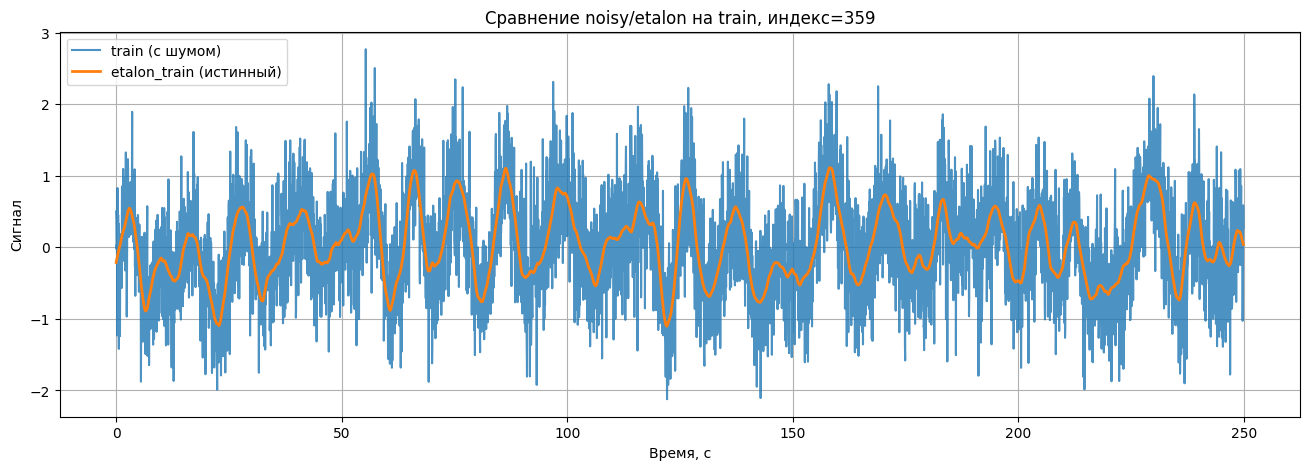

In [5]:
rand_idx = np.random.randint(0, train.shape[0])

dt = 0.05
t = np.arange(train.shape[1]) * dt

plt.figure(figsize=(16, 5))
plt.plot(t, train[rand_idx], label='train (с шумом)', alpha=0.8)
plt.plot(t, etalon_train[rand_idx], label='etalon_train (истинный)', linewidth=2)
plt.xlabel('Время, с')
plt.ylabel('Сигнал')
plt.title(f'Сравнение noisy/etalon на train, индекс={rand_idx}')
plt.grid(True)
plt.legend()
plt.show()


## 3. Формирование признаков и целевой переменной

По условию используем первые 4000 отсчетов (200 с) для прогноза следующих 1000 отсчетов (50 с).

Для обучения берем **истинный сигнал** (`etalon_train`) как target, чтобы модель училась восстанавливать полезный сигнал, а не шум.


In [6]:
train_size = 4000

X_train = train[:, :train_size]
y_train = etalon_train[:, train_size:]

X_test = test[:, :train_size]
y_test = etalon_test[:, train_size:]

print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")


X_train: (1000, 4000)
y_train: (1000, 1000)
X_test: (500, 4000)
y_test: (500, 1000)


## 4. Обучение модели

Используем `Ridge` (L2-регуляризация) в пайплайне со стандартизацией.
Это устойчивая линейная модель для многомерной регрессии с большим числом признаков.


In [7]:
model = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=15.0, random_state=42))
])

model.fit(X_train, y_train)
test_preds = model.predict(X_test)

print('Predictions shape:', test_preds.shape)


Predictions shape: (500, 1000)


## 5. Метрики из задания (ME и СКП)

- ME(t): среднее значение ошибки прогноза по множеству реализаций.
- СКП(t): действительная среднеквадратическая погрешность с вычитанием смещения ME(t).


In [8]:
error = test_preds - y_test

mean_error_t = np.mean(error, axis=0)
rms_t = np.sqrt(np.mean((error - mean_error_t) ** 2, axis=0))

print(f"Среднее значение ME по горизонту: {mean_error_t.mean():.6f}")
print(f"Среднее значение СКП по горизонту: {rms_t.mean():.6f}")
print(f"MAE (доп.): {mean_absolute_error(y_test, test_preds):.6f}")
print(f"RMSE (доп.): {root_mean_squared_error(y_test, test_preds):.6f}")


Среднее значение ME по горизонту: 0.007779
Среднее значение СКП по горизонту: 0.580974
MAE (доп.): 0.465747
RMSE (доп.): 0.581688


## 6. Графики качества прогноза


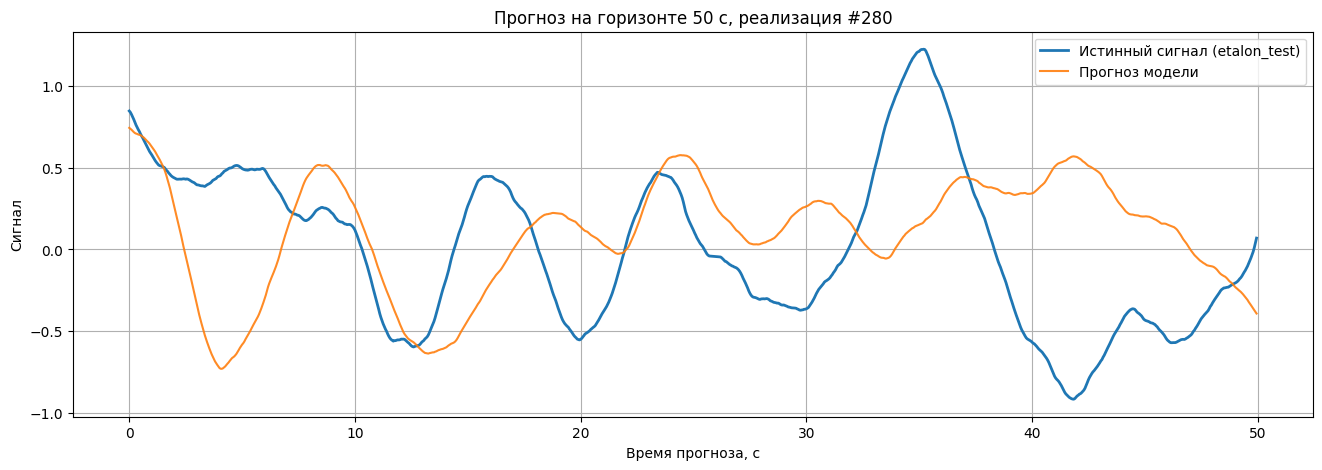

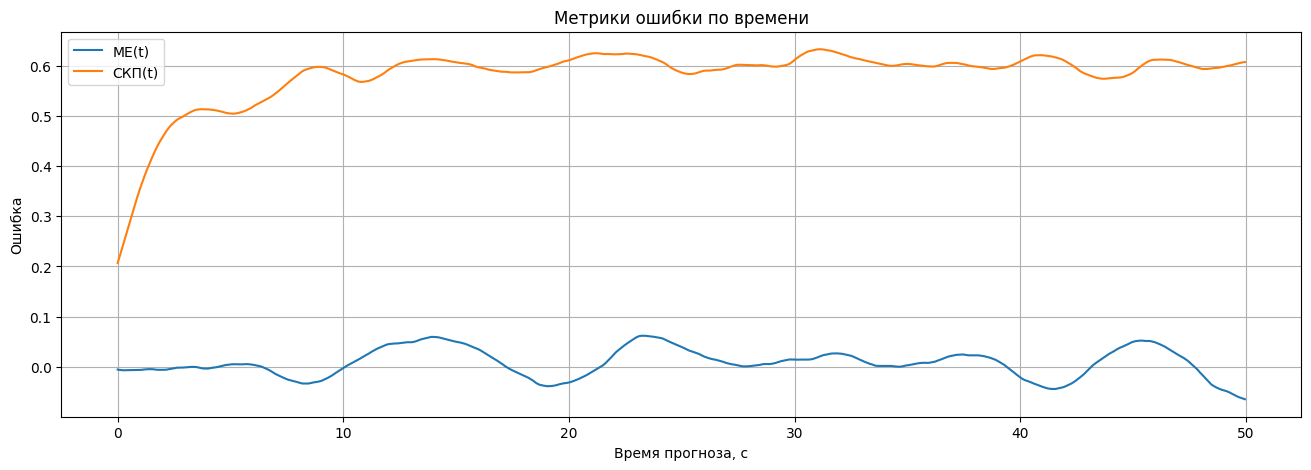

In [9]:
rand_idx = np.random.randint(0, test_preds.shape[0])
t_forecast = np.arange(test_preds.shape[1]) * dt

plt.figure(figsize=(16, 5))
plt.plot(t_forecast, y_test[rand_idx], label='Истинный сигнал (etalon_test)', linewidth=2)
plt.plot(t_forecast, test_preds[rand_idx], label='Прогноз модели', alpha=0.9)
plt.xlabel('Время прогноза, с')
plt.ylabel('Сигнал')
plt.title(f'Прогноз на горизонте 50 с, реализация #{rand_idx}')
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(16, 5))
plt.plot(t_forecast, mean_error_t, label='ME(t)')
plt.plot(t_forecast, rms_t, label='СКП(t)')
plt.xlabel('Время прогноза, с')
plt.ylabel('Ошибка')
plt.title('Метрики ошибки по времени')
plt.grid(True)
plt.legend()
plt.show()
